In [1]:
# Capestone Project: France

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings("ignore")

In [3]:
france_df = pd.read_csv("France.csv")
france_df.head()

,ID,Host ID,Host Name,Host Since,Host Response Rate,Host Listings Count,Host Total Listings Count,City,State,Zipcode,Country,Property Type,Room Type,Accommodates,Bathrooms,Bedrooms,Beds,Bed Type,Amenities,Price,Weekly Price,Monthly Price,Security Deposit,Cleaning Fee,Guests Included,Extra People,Minimum Nights,Maximum Nights,Number of Reviews,Review Scores Rating,Cancellation Policy,Reviews per Month
0,6165738,31986651,Bernard,42120.0,100.0,1.0,1.0,Thoiry,Rhône-Alpes,1710,France,Loft,Private room,2,2.0,1.0,1.0,Real Bed,"TV,Wireless Internet,Air Conditioning,Kitchen,...",44.0,258.0,NaN,NaN,NaN,1,0,1,1125,0,NaN,flexible,NaN
1,13908935,82489826,Enice,42559.0,100.0,1.0,1.0,Gaillard,Auvergne Rhône-Alpes,74240,France,Apartment,Entire home/apt,2,1.0,1.0,1.0,Pull-out Sofa,"TV,Internet,Wireless Internet,Kitchen,Free Par...",39.0,NaN,NaN,560.0,28.0,1,6,2,30,1,80.0,moderate,1.00
2,7713011,32492446,Vincent,42127.0,100.0,7.0,7.0,Paris,Île-de-France,75018,France,Apartment,Entire home/apt,2,1.0,0.0,1.0,Real Bed,"TV,Cable TV,Internet,Wireless Internet,Kitchen...",80.0,NaN,NaN,100.0,30.0,1,5,4,365,37,85.0,strict,1.84
3,3335054,2726446,Pascale,41084.0,NaN,1.0,1.0,Paris,Île-de-France,75018,France,Apartment,Entire home/apt,2,1.0,0.0,1.0,Pull-out Sofa,"Cable TV,Wireless Internet,Kitchen,Elevator in...",65.0,385.0,1250.0,150.0,15.0,1,0,3,1125,1,100.0,moderate,0.03
4,10066518,30432969,Lea,42095.0,95.0,2.0,2.0,Paris,Île-de-France,75018,France,Apartment,Entire home/apt,2,1.0,1.0,1.0,Real Bed,"Internet,Wireless Internet,Kitchen,Indoor fire...",41.0,340.0,NaN,NaN,15.0,1,0,2,1125,13,97.0,moderate,0.89


### DATA PREPROCESSING PROCESS

In [4]:
france_df.columns = france_df.columns.str.lower().str.replace(" ", "_")


numeric_cols_france = [
    "host_response_rate", "host_listings_count", "host_total_listings_count",
    "accommodates", "bathrooms", "bedrooms", "beds", "price",
    "weekly_price", "monthly_price", "security_deposit",
    "cleaning_fee", "guests_included", "extra_people",
    "minimum_nights", "maximum_nights", "number_of_reviews",
    "review_scores_rating", "reviews_per_month"
]

for col in numeric_cols_france:
    france_df[col] = pd.to_numeric(france_df[col], errors="coerce")

# Changing Date Format

france_df["host_since"] = pd.to_numeric(france_df["host_since"], errors="coerce")
france_df["host_since"] = (
    pd.to_datetime("1899-12-30") +
    pd.to_timedelta(france_df["host_since"], unit="D")
)

france_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56562 entries, 0 to 56561
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id                         56562 non-null  int64         
 1   host_id                    56562 non-null  int64         
 2   host_name                  56551 non-null  object        
 3   host_since                 56551 non-null  datetime64[ns]
 4   host_response_rate         37832 non-null  float64       
 5   host_listings_count        56551 non-null  float64       
 6   host_total_listings_count  56551 non-null  float64       
 7   city                       56532 non-null  object        
 8   state                      56489 non-null  object        
 9   zipcode                    55821 non-null  object        
 10  country                    56562 non-null  object        
 11  property_type              56562 non-null  object        
 12  room

### MISSING VALUE ANALYSIS

In [5]:
print("Before Missing Value Treatment")
france_df.isnull().sum()

Before Missing Value Treatment


id                               0
host_id                          0
host_name                       11
host_since                      11
host_response_rate           18730
host_listings_count             11
host_total_listings_count       11
city                            30
state                           73
zipcode                        741
country                          0
property_type                    0
room_type                        0
accommodates                     0
bathrooms                      184
bedrooms                       134
beds                            75
bed_type                         0
amenities                      428
price                           57
weekly_price                 40234
monthly_price                44214
security_deposit             25435
cleaning_fee                 20762
guests_included                  0
extra_people                     0
minimum_nights                   0
maximum_nights                   0
number_of_reviews   

In [6]:
# Drop Highly Missing Columns
# As there is more than 85% of data is missing in this columns and fill Na with zeroes
france_df = france_df.drop(columns=['monthly_price', 'weekly_price'])

cols_to_fill_zero = [
    'host_listings_count', 'host_total_listings_count',
    'security_deposit', 'cleaning_fee',
    'reviews_per_month', 'review_scores_rating'
]

france_df[cols_to_fill_zero] = france_df[cols_to_fill_zero].fillna(0)


france_df['host_response_rate'] = france_df['host_response_rate'].fillna(
    france_df['host_response_rate'].median()
)

france_df['price'] = france_df['price'].fillna(
    france_df['price'].median()
)


mode_cols = ['amenities', 'beds', 'bedrooms','bathrooms', 'host_name','host_since', 'zipcode']

for col in mode_cols:
    france_df[col] = france_df[col].fillna(france_df[col].mode()[0])

### Zipcode, City and State Cleaning

In [7]:
france_df['zipcode'].nunique()

83

In [8]:
france_df['zipcode'].unique()

array(['1710', '74240', '75018', '75004', '75003', '75017', '92110',
       '75019', '75020', '75007', '75015', '75006', '75010', '93500',
       '93310', '75009', '93300', '75012', '95170', '75011', '75008',
       '75013', '92130', '75005', '75002', '75001', '94220', '75014',
       '92300', '94200', '74160', '94270', '93400', '75116', '75016',
       '92200', '92100', '750018', '93170', '1210', '94160', '94250',
       '92120', '94410', '75', '75011\n75011', '92170', '94340', '94120',
       'Paris 75004', '75000', '74400', '94300', 'adf', '76016', '98712',
       '93200', '75011 PARIS', '93260', '74100', '1280', '7015', '750109',
       '92150', '92240', 'N', '93100', '93210', '74140', '74580',
       '750016', '92210', '75003\n75003', 'Paris', '700014', '75 018',
       '94130', '75014\n75014', 'Montmartre', '78005', '78008', '75018e',
       '75106'], dtype=object)

In [9]:
france_df['city'].nunique()

138

In [10]:
france_df['city'].unique()

array(['Thoiry', 'Gaillard', 'Paris', 'Paris-18E-Arrondissement', 'paris',
       'Clichy', 'Paris-10E-Arrondissement', 'Pantin',
       'Paris-19E-Arrondissement', 'Le Pré-Saint-Gervais',
       'Deuil-la-Barre', nan, 'Paris-15E-Arrondissement',
       'Issy les Moulineaux', 'Paris-12E-Arrondissement',
       'Paris-1ER-Arrondissement', 'Charenton-le-Pont',
       'Paris 6e arrondissement', 'Paris-6E-Arrondissement',
       'Paris-8E-Arrondissement', 'Levallois-Perret',
       'Paris-3E-Arrondissement', 'Paris-20E-Arrondissement',
       'Paris-11E-Arrondissement', 'Ivry-sur-Seine',
       'Paris-13E-Arrondissement', 'PARIS', 'Paris-2E-Arrondissement',
       'Collonges-sous-Salève', 'Archamps', 'Saint-Julien-en-Genevois',
       'Paris-17E-Arrondissement', 'Le Kremlin-Bicêtre',
       'Paris-4E-Arrondissement', 'Saint-Ouen',
       'Paris-14E-Arrondissement', 'Neuilly-sur-Seine',
       'Boulogne-Billancourt', 'Paris-16E-Arrondissement', 'Bagnolet',
       'Issy-les-Moulineaux', 'gai

In [11]:
france_df['state'].nunique()

62

In [12]:
france_df['state'].unique()

array(['Rhône-Alpes', 'Auvergne Rhône-Alpes', 'Île-de-France', 'IDF',
       'paris', 'Ile-de-France', 'Paris', 'Île-de-Francs', 'France',
       'Île de France', 'ile de france', 'Rhone-Alpes', nan,
       'Ile de France', 'Ile de france', 'RA', 'Pigalle',
       'Isla de Francia', 'Ã\x8ele-de-France', '3', 'Seine saint Denis',
       'Île de france', 'Paris, Île-de-France, FR', 'Iles-de-France',
       'le marais', 'Ilha de França', 'IdF', 'Champs-Élysées',
       'Iles de France', 'Heart of Montparnasse', 'Montmartre',
       'Îles Marquises', 'Isle-De-France', '75', 'FRANCE',
       'île de France', 'Refait à neuf', 'FR', 'france',
       'Auvergne-Rhône-Alpes', 'paris 12ème', '法兰西岛',
       'Saint-Germain-des-Prés', '法蘭西島', 'Centre', 'Región Île-de-France',
       'HAUTS-DE-SEIN', 'idf', '일 드 프랑스', 'IDF bis', 'Bon', 'francia',
       'PARIS', 'ile de France', 'Burgundy', '法兰西堡', 'Il de France',
       'Idf', '-', 'Refait a neuf', 'Pairs', 'Bastille', 'R'],
      dtype=object)

In [13]:
# Dictionary to fix known zipcode issues
zip_fix_dict = {
    '1710': np.nan, '1210': np.nan, '1280': np.nan, '7015': np.nan,
    'adf': np.nan, 'N': np.nan, 'Paris': np.nan,
    '750018': '75018', '750109': '75010', '750016': '75016',
    '75014\n75014': '75014', 'Montmartre': '75018',
    '75018e': '75018', 'Paris 75004': '75004',
    '75011 PARIS': '75011'
}

france_df["zipcode"] = france_df["zipcode"].astype(str).replace(zip_fix_dict)

france_df.loc[france_df["zipcode"].str.len() != 5, "zipcode"] = np.nan

france_df["zipcode"] = france_df["zipcode"].fillna(france_df["zipcode"].mode()[0])

print(france_df['zipcode'].unique())

['75018' '74240' '75004' '75003' '75017' '92110' '75019' '75020' '75007'
 '75015' '75006' '75010' '93500' '93310' '75009' '93300' '75012' '95170'
 '75011' '75008' '75013' '92130' '75005' '75002' '75001' '94220' '75014'
 '92300' '94200' '74160' '94270' '93400' '75116' '75016' '92200' '92100'
 '93170' '94160' '94250' '92120' '94410' '92170' '94340' '94120' '75000'
 '74400' '94300' '76016' '98712' '93200' '93260' '74100' '92150' '92240'
 '93100' '93210' '74140' '74580' '92210' '94130' '78005' '78008' '75106']


In [14]:
france_df = france_df.dropna(subset=['city', 'state'])

In [15]:
# Cleaning and Standardizing City Names
# This function removes noise, multilingual values,
# arrondissement details, and standardizes city names

# CHANGING CITY COLUMN 

city_mapping = {
    # --- Paris Arrondissements ---
    '75000': 'Paris', '75001': 'Paris', '75002': 'Paris', '75003': 'Paris', 
    '75004': 'Paris', '75005': 'Paris', '75006': 'Paris', '75007': 'Paris', 
    '75008': 'Paris', '75009': 'Paris', '75010': 'Paris', '75011': 'Paris', 
    '75012': 'Paris', '75013': 'Paris', '75014': 'Paris', '75015': 'Paris', 
    '75016': 'Paris', '75017': 'Paris', '75018': 'Paris', '75019': 'Paris', 
    '75020': 'Paris', '75116': 'Paris', '75106': 'Paris',

    # --- Hauts-de-Seine (92) ---
    '92100': 'Boulogne-Billancourt', '92110': 'Clichy', '92120': 'Montrouge', 
    '92130': 'Issy-les-Moulineaux', '92150': 'Suresnes', '92170': 'Vanves', 
    '92200': 'Neuilly-sur-Seine', '92210': 'Saint-Cloud', '92240': 'Malakoff', 
    '92300': 'Levallois-Perret',

    # --- Seine-Saint-Denis (93) ---
    '93100': 'Montreuil', '93170': 'Bagnolet', '93200': 'Saint-Denis', 
    '93210': 'La Plaine Saint-Denis', '93260': 'Les Lilas', '93300': 'Aubervilliers', 
    '93310': 'Le Pré-Saint-Gervais', '93400': 'Saint-Ouen', '93500': 'Pantin',

    # --- Val-de-Marne (94) ---
    '94120': 'Fontenay-sous-Bois', '94130': 'Nogent-sur-Marne', '94160': 'Saint-Mandé', 
    '94200': 'Ivry-sur-Seine', '94220': 'Charenton-le-Pont', '94250': 'Gentilly', 
    '94270': 'Le Kremlin-Bicêtre', '94300': 'Vincennes', '94340': 'Joinville-le-Pont', 
    '94410': 'Saint-Maurice',

    # --- Haute-Savoie (74) ---
    '74100': 'Annemasse', '74140': 'Douvaine', '74160': 'Archamps', 
    '74240': 'Gaillard', '74400': 'Chamonix-Mont-Blanc', '74580': 'Viry',

    # --- Others ---
    '95170': 'Deuil-la-Barre', '76016': 'Saint-Adrien', '78005': 'Versailles', 
    '78008': 'Versailles', '98712': 'Pirae (Tahiti)'
}   

france_df['city'] = france_df['zipcode'].map(city_mapping)

print(france_df['city'].unique())

['Paris' 'Gaillard' 'Clichy' 'Pantin' 'Le Pré-Saint-Gervais'
 'Aubervilliers' 'Deuil-la-Barre' 'Issy-les-Moulineaux'
 'Charenton-le-Pont' 'Levallois-Perret' 'Ivry-sur-Seine' 'Archamps'
 'Le Kremlin-Bicêtre' 'Saint-Ouen' 'Neuilly-sur-Seine'
 'Boulogne-Billancourt' 'Bagnolet' 'Saint-Mandé' 'Gentilly' 'Montrouge'
 'Saint-Maurice' 'Vanves' 'Joinville-le-Pont' 'Fontenay-sous-Bois'
 'Chamonix-Mont-Blanc' 'Vincennes' 'Saint-Adrien' 'Pirae (Tahiti)'
 'Saint-Denis' 'Les Lilas' 'Annemasse' 'Suresnes' 'Malakoff' 'Montreuil'
 'La Plaine Saint-Denis' 'Douvaine' 'Viry' 'Saint-Cloud'
 'Nogent-sur-Marne' 'Versailles']


In [16]:
# CHANGING STATE COLUMN

city_to_state = {
    # --- Île-de-France (Main Region) ---
    'Paris': 'Île-de-France',
    'Clichy': 'Île-de-France',
    'Pantin': 'Île-de-France',
    'Le Pré-Saint-Gervais': 'Île-de-France',
    'Aubervilliers': 'Île-de-France',
    'Deuil-la-Barre': 'Île-de-France',
    'Issy-les-Moulineaux': 'Île-de-France',
    'Charenton-le-Pont': 'Île-de-France',
    'Levallois-Perret': 'Île-de-France',
    'Ivry-sur-Seine': 'Île-de-France',
    'Le Kremlin-Bicêtre': 'Île-de-France',
    'Saint-Ouen': 'Île-de-France',
    'Neuilly-sur-Seine': 'Île-de-France',
    'Boulogne-Billancourt': 'Île-de-France',
    'Bagnolet': 'Île-de-France',
    'Saint-Mandé': 'Île-de-France',
    'Gentilly': 'Île-de-France',
    'Montrouge': 'Île-de-France',
    'Saint-Maurice': 'Île-de-France',
    'Vanves': 'Île-de-France',
    'Joinville-le-Pont': 'Île-de-France',
    'Fontenay-sous-Bois': 'Île-de-France',
    'Vincennes': 'Île-de-France',
    'Saint-Denis': 'Île-de-France',
    'Les Lilas': 'Île-de-France',
    'Suresnes': 'Île-de-France',
    'Malakoff': 'Île-de-France',
    'Montreuil': 'Île-de-France',
    'La Plaine Saint-Denis': 'Île-de-France',
    'Saint-Cloud': 'Île-de-France',
    'Nogent-sur-Marne': 'Île-de-France',
    'Versailles': 'Île-de-France',

    # --- Auvergne-Rhône-Alpes ---
    'Gaillard': 'Auvergne-Rhône-Alpes',
    'Archamps': 'Auvergne-Rhône-Alpes',
    'Chamonix-Mont-Blanc': 'Auvergne-Rhône-Alpes',
    'Annemasse': 'Auvergne-Rhône-Alpes',
    'Douvaine': 'Auvergne-Rhône-Alpes',
    'Viry': 'Auvergne-Rhône-Alpes',

    # --- Normandy ---
    'Saint-Adrien': 'Normandy',

    # --- Overseas (French Polynesia) ---
    'Pirae (Tahiti)': 'French Polynesia'
}

france_df['state'] = france_df['city'].map(city_to_state)

print(france_df['state'].unique())

['Île-de-France' 'Auvergne-Rhône-Alpes' 'Normandy' 'French Polynesia']


In [17]:
print("After Missing Value Treatment")
france_df.isnull().sum()

After Missing Value Treatment


id                           0
host_id                      0
host_name                    0
host_since                   0
host_response_rate           0
host_listings_count          0
host_total_listings_count    0
city                         0
state                        0
zipcode                      0
country                      0
property_type                0
room_type                    0
accommodates                 0
bathrooms                    0
bedrooms                     0
beds                         0
bed_type                     0
amenities                    0
price                        0
security_deposit             0
cleaning_fee                 0
guests_included              0
extra_people                 0
minimum_nights               0
maximum_nights               0
number_of_reviews            0
review_scores_rating         0
cancellation_policy          0
reviews_per_month            0
dtype: int64

### OUTLIERS ANALYSIS

In [18]:
# Identifying Outliers

num_cols = france_df.select_dtypes(include=['int64', 'float64']).columns

outlier_summary_before = {}

for col in num_cols:
    Q1 = france_df[col].quantile(0.25)
    Q3 = france_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = france_df[
        (france_df[col] < lower_limit) | (france_df[col] > upper_limit)
    ].shape[0]

    outlier_summary_before[col] = outliers

outlier_summary_before

{'id': 0,
 'host_id': 3364,
 'host_response_rate': 11156,
 'host_listings_count': 6170,
 'host_total_listings_count': 6170,
 'accommodates': 728,
 'bathrooms': 6217,
 'bedrooms': 22772,
 'beds': 3235,
 'price': 4509,
 'security_deposit': 1187,
 'cleaning_fee': 1540,
 'guests_included': 13928,
 'extra_people': 2723,
 'minimum_nights': 3798,
 'maximum_nights': 42,
 'number_of_reviews': 6137,
 'review_scores_rating': 0,
 'reviews_per_month': 4646}

In [19]:
exclude_cols = [
    'host_id', 'guests_included', 'host_listings_count',
    'host_response_rate', 'bathrooms',
    'bedrooms', 'beds', 'price'
]

num_cols = france_df.select_dtypes(include=['int64', 'float64']).columns
num_cols = [col for col in num_cols if col not in exclude_cols]

for col in num_cols:
    Q1 = france_df[col].quantile(0.25)
    Q3 = france_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    france_df[col] = france_df[col].mask(france_df[col] < lower_limit, lower_limit)
    france_df[col] = france_df[col].mask(france_df[col] > upper_limit, upper_limit)

In [20]:
num_cols = france_df.select_dtypes(include=['int64', 'float64']).columns
num_cols = [col for col in num_cols if col not in exclude_cols]

outlier_summary_after = {}

for col in num_cols:
    Q1 = france_df[col].quantile(0.25)
    Q3 = france_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = france_df[
        (france_df[col] < lower_limit) | (france_df[col] > upper_limit)].shape[0]

    outlier_summary_after[col] = outliers

outlier_summary_after

{'id': 0,
 'host_total_listings_count': 0,
 'accommodates': 0,
 'security_deposit': 0,
 'cleaning_fee': 0,
 'extra_people': 0,
 'minimum_nights': 0,
 'maximum_nights': 0,
 'number_of_reviews': 0,
 'review_scores_rating': 0,
 'reviews_per_month': 0}

In [21]:
count_columns = ["accommodates", "number_of_reviews", "guests_included"]

for column in count_columns:
    france_df[column] = (pd.to_numeric(france_df[column], errors="coerce").round().astype("Int64"))

In [22]:
# Featuring Date and Amenities Columns

In [23]:
# Date Columns
# Extract year,month number, month name, week number

france_df["host_year"] = france_df["host_since"].dt.year
france_df["host_month"] = france_df["host_since"].dt.month
france_df["host_month_name"] = france_df["host_since"].dt.month_name()
france_df["host_week"] = france_df["host_since"].dt.isocalendar().week

In [24]:
france_df["amenities"] = france_df["amenities"].fillna("")

amenities_clean_list = []
amenity_count_list = []

for value in france_df["amenities"]:
    
    value = str(value)
    
    split_items = value.split(",")
    
    clean_items = []
    
    for item in split_items:
        item = item.strip()
        
        if item == "" or item.lower() == "nan":
            continue
        
        if item.startswith("translation"):
            continue
        
        clean_items.append(item)
    
    amenity_count_list.append(len(clean_items))
    
    if len(clean_items) == 0:
        amenities_clean_list.append("No Amenities Listed")
    else:
        amenities_clean_list.append(", ".join(clean_items))

france_df["amenities_clean"] = amenities_clean_list
france_df["amenity_count"] = amenity_count_list

In [25]:
france_df.head()

,id,host_id,host_name,host_since,host_response_rate,host_listings_count,host_total_listings_count,city,state,zipcode,country,property_type,room_type,accommodates,bathrooms,bedrooms,beds,bed_type,amenities,price,security_deposit,cleaning_fee,guests_included,extra_people,minimum_nights,maximum_nights,number_of_reviews,review_scores_rating,cancellation_policy,reviews_per_month,host_year,host_month,host_month_name,host_week,amenities_clean,amenity_count
0,6165738,31986651,Bernard,2015-04-26,100.0,1.0,1.0,Paris,Île-de-France,75018,France,Loft,Private room,2,2.0,1.0,1.0,Real Bed,"TV,Wireless Internet,Air Conditioning,Kitchen,...",44.0,0.0,0.0,1,0,1,1125.0,0,0.0,flexible,0.00,2015,4,April,17,"TV, Wireless Internet, Air Conditioning, Kitch...",19
1,13908935,82489826,Enice,2016-07-08,100.0,1.0,1.0,Gaillard,Auvergne-Rhône-Alpes,74240,France,Apartment,Entire home/apt,2,1.0,1.0,1.0,Pull-out Sofa,"TV,Internet,Wireless Internet,Kitchen,Free Par...",39.0,560.0,28.0,1,6,2,30.0,1,80.0,moderate,1.00,2016,7,July,27,"TV, Internet, Wireless Internet, Kitchen, Free...",13
2,7713011,32492446,Vincent,2015-05-03,100.0,7.0,3.5,Paris,Île-de-France,75018,France,Apartment,Entire home/apt,2,1.0,0.0,1.0,Real Bed,"TV,Cable TV,Internet,Wireless Internet,Kitchen...",80.0,100.0,30.0,1,5,4,365.0,37,85.0,strict,1.84,2015,5,May,18,"TV, Cable TV, Internet, Wireless Internet, Kit...",11
3,3335054,2726446,Pascale,2012-06-24,100.0,1.0,1.0,Paris,Île-de-France,75018,France,Apartment,Entire home/apt,2,1.0,0.0,1.0,Pull-out Sofa,"Cable TV,Wireless Internet,Kitchen,Elevator in...",65.0,150.0,15.0,1,0,3,1125.0,1,100.0,moderate,0.03,2012,6,June,25,"Cable TV, Wireless Internet, Kitchen, Elevator...",8
4,10066518,30432969,Lea,2015-04-01,95.0,2.0,2.0,Paris,Île-de-France,75018,France,Apartment,Entire home/apt,2,1.0,1.0,1.0,Real Bed,"Internet,Wireless Internet,Kitchen,Indoor fire...",41.0,0.0,15.0,1,0,2,1125.0,13,97.0,moderate,0.89,2015,4,April,14,"Internet, Wireless Internet, Kitchen, Indoor f...",16


In [26]:
france_df.to_csv("France_Cleaned.csv", index=False)
print("Cleaned file saved as France_Cleaned.csv")

Cleaned file saved as France_Cleaned.csv


# AirBnb France Analysis

In [27]:
france_df = pd.read_csv("France_Cleaned.csv")
france_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56462 entries, 0 to 56461
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         56462 non-null  int64  
 1   host_id                    56462 non-null  int64  
 2   host_name                  56462 non-null  object 
 3   host_since                 56462 non-null  object 
 4   host_response_rate         56462 non-null  float64
 5   host_listings_count        56462 non-null  float64
 6   host_total_listings_count  56462 non-null  float64
 7   city                       56462 non-null  object 
 8   state                      56462 non-null  object 
 9   zipcode                    56462 non-null  int64  
 10  country                    56462 non-null  object 
 11  property_type              56462 non-null  object 
 12  room_type                  56462 non-null  object 
 13  accommodates               56462 non-null  int

## Listing & Host Performance Analysis 

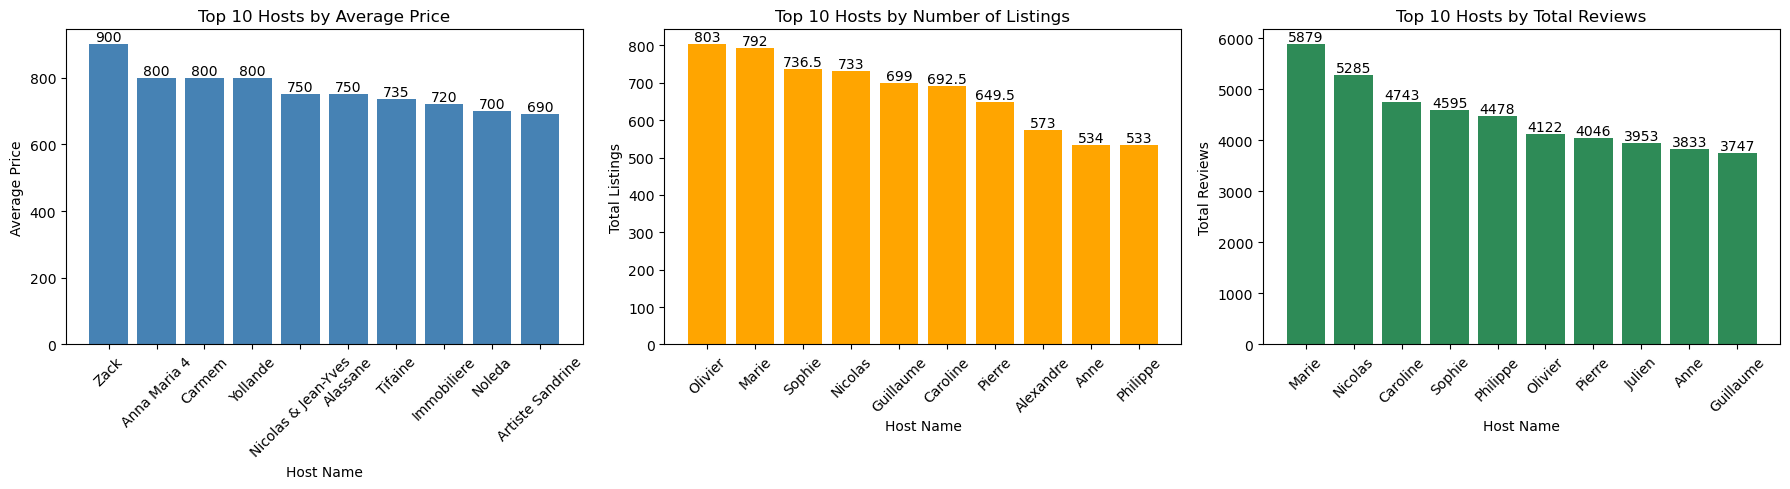

In [28]:
plt.figure(figsize=(18, 5))

# TOP 10 HOSTS BY AVERAGE PRICE
plt.subplot(1, 3, 1)

top_price_hosts = (france_df.groupby("host_name")["price"].mean().sort_values(ascending=False).head(10).reset_index())

ax1 = plt.bar(top_price_hosts["host_name"],top_price_hosts["price"],color="steelblue")

plt.bar_label(ax1, fmt="%.0f")
plt.title("Top 10 Hosts by Average Price")
plt.xlabel("Host Name")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

# TOP 10 HOSTS BY NUMBER OF LISTINGS
plt.subplot(1, 3, 2)

top_listing_hosts = (france_df.groupby("host_name")["host_total_listings_count"].sum().sort_values(ascending=False).head(10).reset_index())

ax2 = plt.bar(top_listing_hosts["host_name"],top_listing_hosts["host_total_listings_count"],color="orange")

plt.bar_label(ax2)
plt.title("Top 10 Hosts by Number of Listings")
plt.xlabel("Host Name")
plt.ylabel("Total Listings")
plt.xticks(rotation=45)

# TOP 10 HOSTS BY TOTAL REVIEWS
plt.subplot(1, 3, 3)

top_review_hosts = (france_df.groupby("host_name")["number_of_reviews"].sum().sort_values(ascending=False).head(10).reset_index())

ax3 = plt.bar(top_review_hosts["host_name"],top_review_hosts["number_of_reviews"],color="seagreen")

plt.bar_label(ax3)
plt.title("Top 10 Hosts by Total Reviews")
plt.xlabel("Host Name")
plt.ylabel("Total Reviews")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Listing and Host Performance - Insights

1. Zack has the highest average listing price (~900), indicating a strong premium pricing strategy, while other top-priced hosts fall within the 750–800 range, reflecting a competitive high-end market.

2. Olivier and Marie manage the highest number of listings (~800 each), clearly identifying them as large-scale hosts compared to others with fewer listings.

3. Marie records the highest total reviews (~5,879), followed by Nicolas and Caroline suggesting that hosts with more listings tend to achieve higher guest engagement and demand.


## Geospatial and Location Analysis 

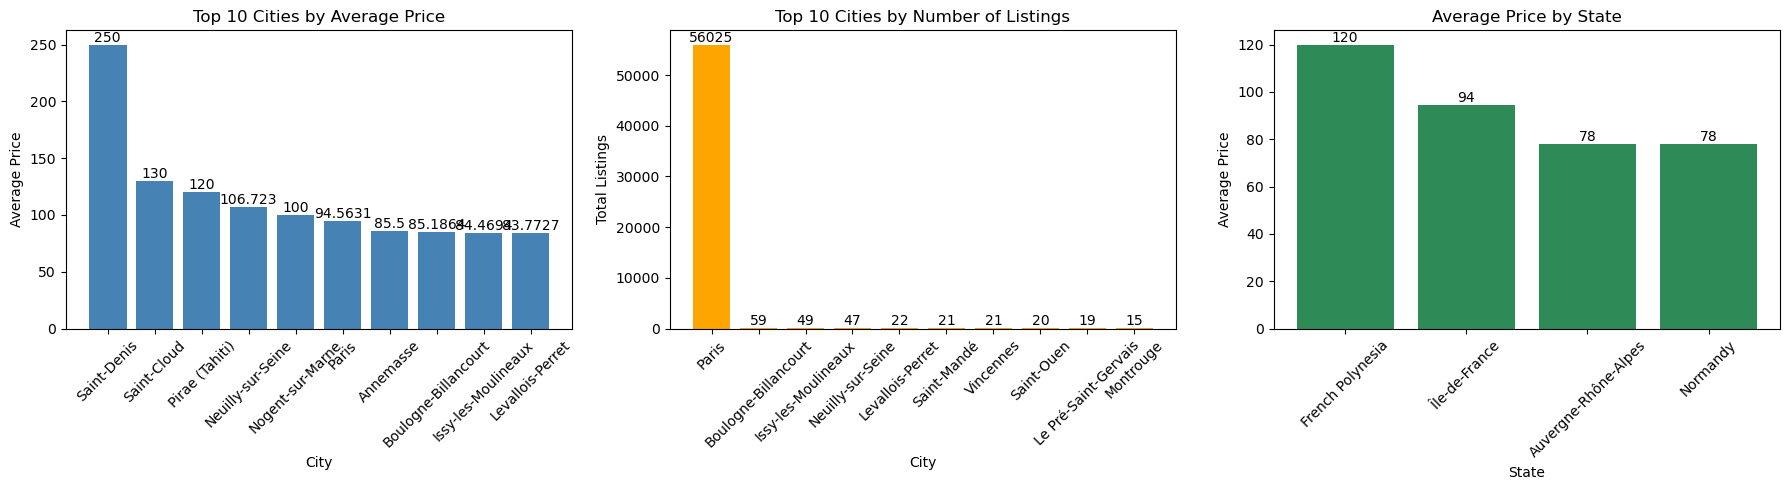

In [29]:
plt.figure(figsize=(18, 5))

# 1. Top 10 Cities by Average Price
plt.subplot(1, 3, 1)

avg_price_city = (france_df.groupby("city")["price"].mean().sort_values(ascending=False).head(10).reset_index())

ax1 = plt.bar(avg_price_city["city"], avg_price_city["price"],color="steelblue")
plt.bar_label(ax1)

plt.title("Top 10 Cities by Average Price")
plt.xlabel("City")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

# 2. Top 10 Cities by Number of Listings
plt.subplot(1, 3, 2)

listing_city = (france_df.groupby("city")["id"].count().sort_values(ascending=False).head(10).reset_index(name="total_listings"))

ax2 = plt.bar(listing_city["city"], listing_city["total_listings"],color="orange")
plt.bar_label(ax2)

plt.title("Top 10 Cities by Number of Listings")
plt.xlabel("City")
plt.ylabel("Total Listings")
plt.xticks(rotation=45)

# 3. Average Price by State
plt.subplot(1, 3, 3)

avg_price_state = (france_df.groupby("state")["price"].mean().sort_values(ascending=False).reset_index())

ax3 = plt.bar(avg_price_state["state"], avg_price_state["price"],color="seagreen")
plt.bar_label(ax3, fmt="%.0f")

plt.title("Average Price by State")
plt.xlabel("State")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Geospatial and Location- Insights

1. Saint-Denis records the highest average price (250), followed by Saint-Cloud and Pirae (Tahiti) (120–130), indicating strong premium pricing in select high-demand locations.

2. Paris overwhelmingly dominates the market with the highest number of listings (~56,000+), clearly establishing it as the most competitive and active Airbnb city.

3. At the state level, French Polynesia shows the highest average price (~120), while Île-de-France follows (~94), highlighting clear regional price differences driven by tourism and urban demand.

## Customer Experience and Satisfaction 

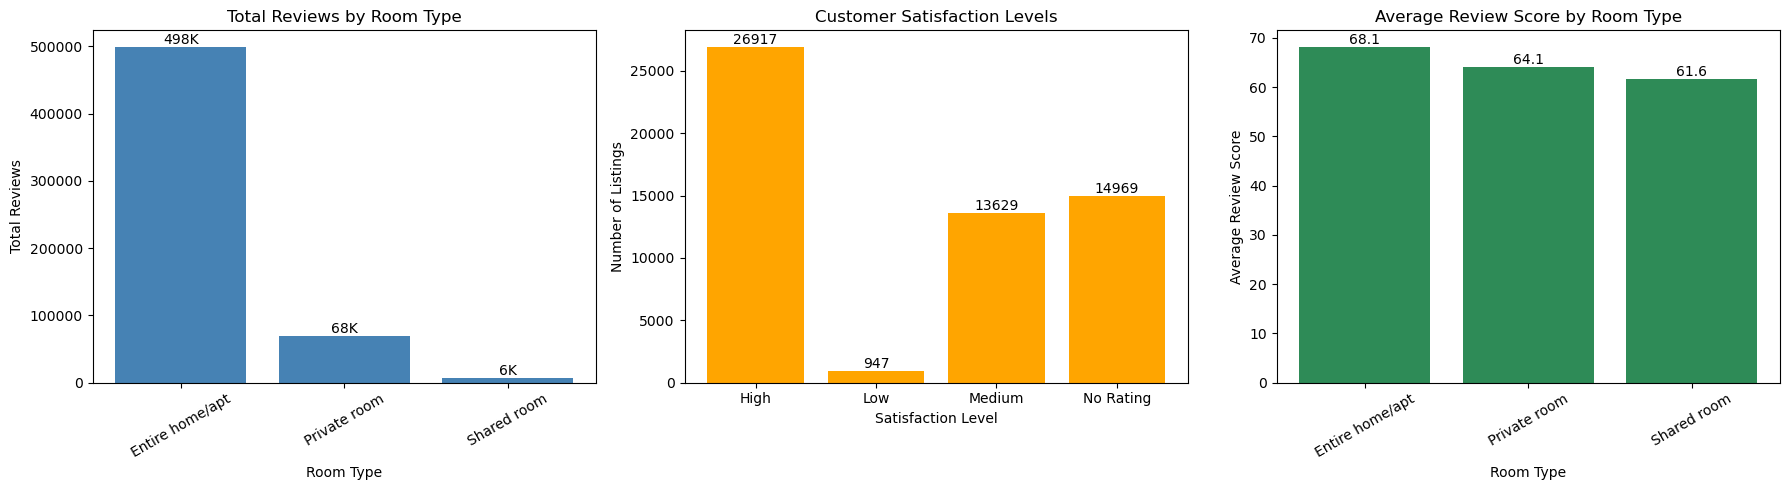

In [30]:
plt.figure(figsize=(18, 5))

# 1. Customer engagement across different room types

plt.subplot(1, 3, 1)

reviews_by_room = (france_df.groupby("room_type")["number_of_reviews"].sum().sort_values(ascending=False))

ax1 = plt.bar(reviews_by_room.index, reviews_by_room.values,color="steelblue")
plt.bar_label(ax1, labels=[f"{int(v/1000)}K" for v in reviews_by_room.values])

plt.title("Total Reviews by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Total Reviews")
plt.xticks(rotation=30)

# 2.  Overall customer satisfaction levels on Airbnb

plt.subplot(1, 3, 2)

france_df["rating_category"] = pd.cut(france_df["review_scores_rating"], bins=[0, 70, 90, 100],labels=["Low", "Medium", "High"])

france_df["rating_category"] = france_df["rating_category"].cat.add_categories("No Rating")
france_df["rating_category"] = france_df["rating_category"].fillna("No Rating")
france_df["rating_category"] = france_df["rating_category"].astype(str)

rating_distribution = france_df["rating_category"].value_counts().sort_index()

ax2 = plt.bar(rating_distribution.index, rating_distribution.values,color="orange")
plt.bar_label(ax2)

plt.title("Customer Satisfaction Levels")
plt.xlabel("Satisfaction Level")
plt.ylabel("Number of Listings")

# 3. Comparison of customer satisfaction across room types

plt.subplot(1, 3, 3)

avg_rating_by_room = (france_df.groupby("room_type")["review_scores_rating"].mean().sort_values(ascending=False))

ax3 = plt.bar(avg_rating_by_room.index, avg_rating_by_room.values,color="seagreen")
plt.bar_label(ax3, fmt="%.1f")

plt.title("Average Review Score by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Review Score")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Customer Experience and Satisfaction – Insights

1. Guests prefer entire home/apartment listings, as they receive far more reviews than private or shared rooms, showing higher customer engagement.

2. Most Airbnb listings have high customer satisfaction, which means guests are generally happy with their stays across different properties.

3. Entire homes also have better average review scores compared to private and shared rooms, indicating that customers tend to be more satisfied when they have more privacy and space.

## Property Attributes & Amenities

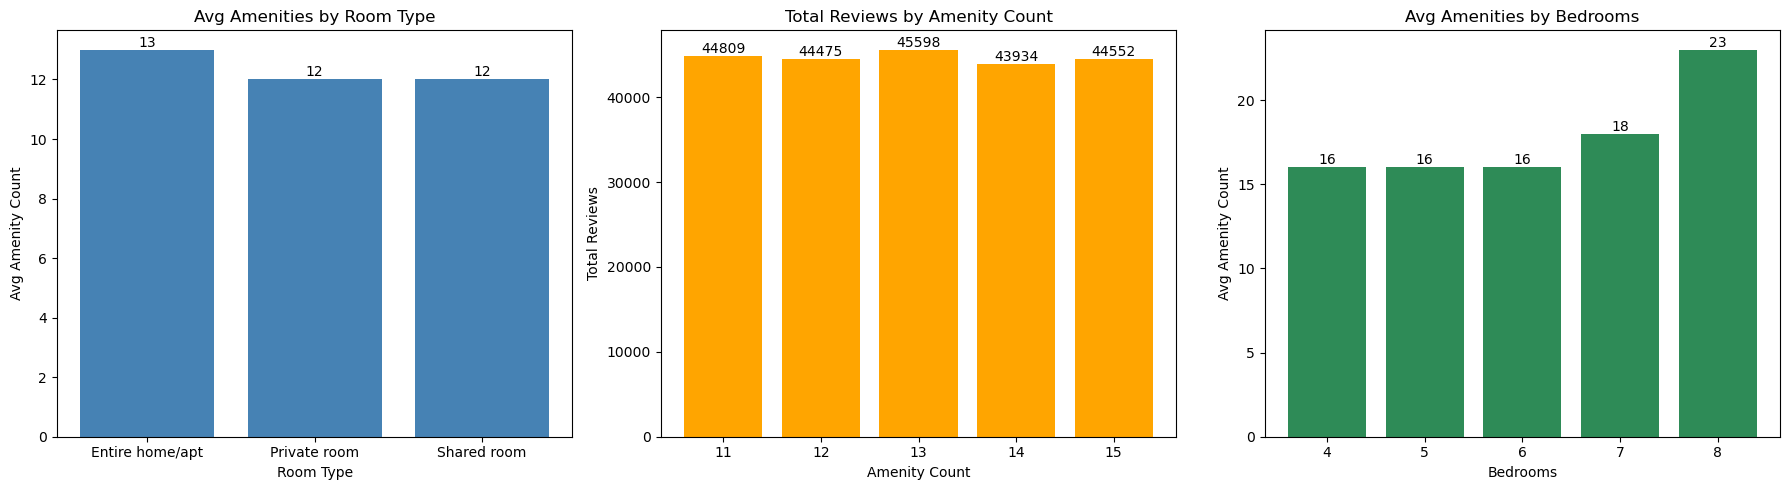

In [31]:
plt.figure(figsize=(18, 5))

# 1. Avg Amenities by Room Type
plt.subplot(1, 3, 1)

room_type_amenity = (france_df.groupby("room_type")["amenity_count"].mean().round().sort_values(ascending=False).head().reset_index())

ax1 = plt.bar(room_type_amenity["room_type"], room_type_amenity["amenity_count"], color="steelblue")
plt.bar_label(ax1)

plt.title("Avg Amenities by Room Type")
plt.ylabel("Avg Amenity Count")
plt.xlabel("Room Type")

# 2. Total Reviews by Amenity Count
plt.subplot(1, 3, 2)

amenity_wise_review = (france_df.groupby("amenity_count")["number_of_reviews"].sum().round().sort_values(ascending=False).head().reset_index())

ax2 = plt.bar(amenity_wise_review["amenity_count"], amenity_wise_review["number_of_reviews"], color="orange")
plt.bar_label(ax2)

plt.title("Total Reviews by Amenity Count")
plt.ylabel("Total Reviews")
plt.xlabel("Amenity Count")

# 3. Avg Amenities by Number of Bedrooms
plt.subplot(1, 3, 3)

no_bedroom_amenity = (france_df.groupby("bedrooms")["amenity_count"].mean().round().sort_values(ascending=False).head().reset_index())

ax3 = plt.bar(no_bedroom_amenity["bedrooms"], no_bedroom_amenity["amenity_count"], color="seagreen")
plt.bar_label(ax3)

plt.title("Avg Amenities by Bedrooms")
plt.ylabel("Avg Amenity Count")
plt.xlabel("Bedrooms")

plt.tight_layout()
plt.show()

## Property Attributes & Amenities – Insights
1. Entire homes generally offer more amenities than private or shared rooms.
This shows that larger or more private listings tend to provide better facilities to guests.

2. Listings with a moderate number of amenities receive the highest reviews.
Adding amenities improves engagement, but beyond a point, more amenities do not significantly increase reviews.

3. Properties with more bedrooms usually provide more amenities.
Bigger homes are better equipped, which makes them suitable for families or group stays.



## Host Insights & Performance

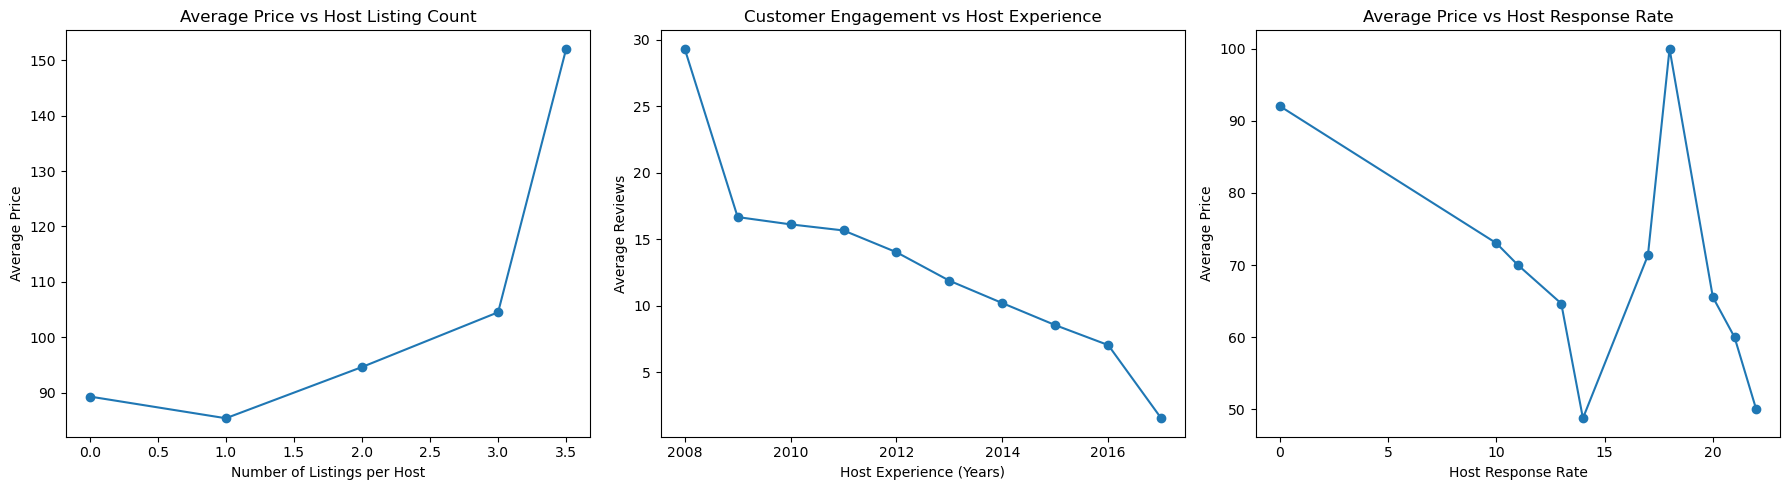

In [32]:
plt.figure(figsize=(18, 5))

# 1. Average Price vs Number of Listings

plt.subplot(1, 3, 1)

avg_price_by_listings = france_df.groupby("host_total_listings_count")["price"].mean().sort_index().head(10)

plt.plot(avg_price_by_listings.index,avg_price_by_listings.values,marker="o")

plt.title("Average Price vs Host Listing Count")
plt.xlabel("Number of Listings per Host")
plt.ylabel("Average Price")


# 2. Reviews Based on Host Listing Count

plt.subplot(1, 3, 2)

france_df["host_since"] = pd.to_datetime(france_df["host_since"], errors="coerce")

avg_reviews_by_experience = france_df.groupby("host_year")["number_of_reviews"].mean().sort_index().head(10)

plt.plot(avg_reviews_by_experience.index,avg_reviews_by_experience.values,marker="o")

plt.title("Customer Engagement vs Host Experience")
plt.xlabel("Host Experience (Years)")
plt.ylabel("Average Reviews")


# 3.  Host Experience and Pricing Trend

plt.subplot(1, 3, 3)

avg_price_by_response = france_df.groupby("host_response_rate")["price"].mean().sort_index().head(10)

plt.plot(avg_price_by_response.index,avg_price_by_response.values,marker="o")

plt.title("Average Price vs Host Response Rate")
plt.xlabel("Host Response Rate")
plt.ylabel("Average Price")

plt.tight_layout()
plt.show()

## Host Insights & Performance – Insights

1. Hosts with more listings generally charge higher prices, especially when they manage three or more properties, showing a move toward professional hosting.

2. Customer engagement increases with host experience, as experienced hosts tend to receive more reviews over time, indicating better visibility and trust.

3. Host response rate does not show a steady impact on pricing, suggesting that while responsiveness matters for service quality, it does not directly control listing prices.

## Demand & Seasonal Trends

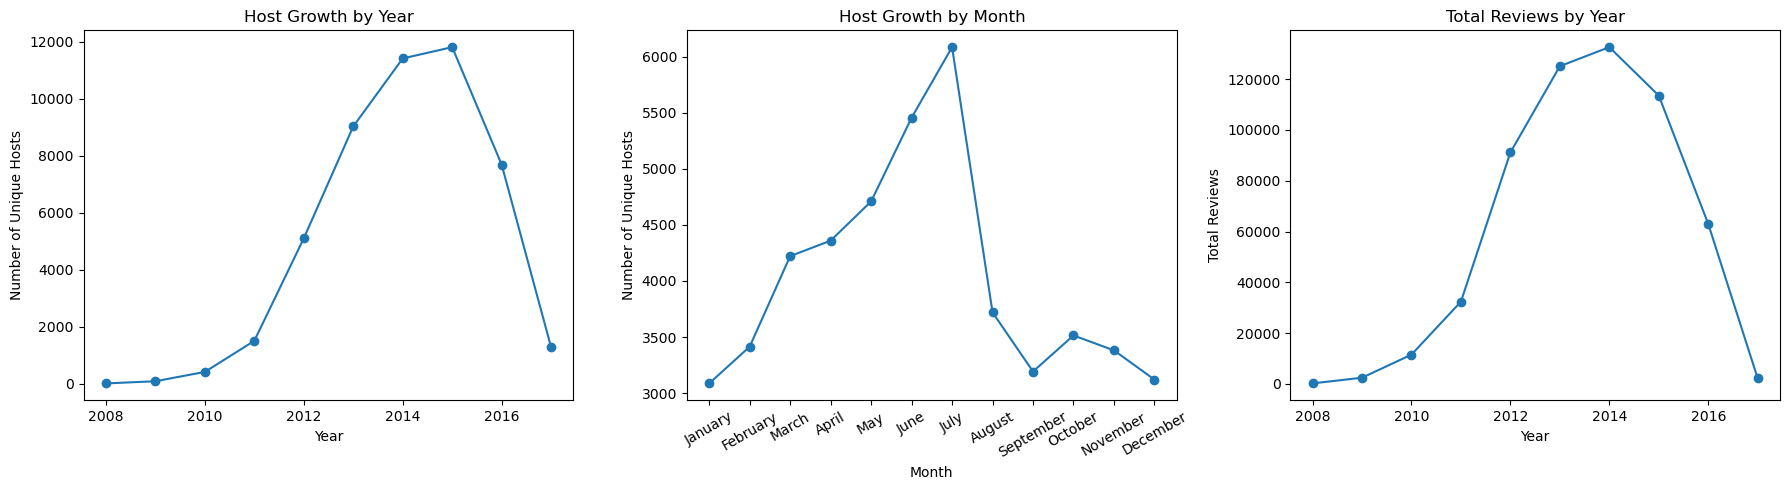

In [33]:
plt.figure(figsize=(18, 5))

# 1. Host growth trend over the years
plt.subplot(1, 3, 1)

hosts_by_year = (france_df.groupby("host_year")["host_id"].nunique().sort_index())

plt.plot(hosts_by_year.index, hosts_by_year.values, marker="o")

plt.title("Host Growth by Year")
plt.xlabel("Year")
plt.ylabel("Number of Unique Hosts")


# 2. Host growth pattern across months
plt.subplot(1, 3, 2)

hosts_by_month = (france_df.groupby("host_month_name")["host_id"].nunique().reindex([
        "January","February","March","April","May","June",
        "July","August","September","October","November","December"
    ]))

plt.plot(hosts_by_month.index, hosts_by_month.values, marker="o")

plt.title("Host Growth by Month")
plt.xlabel("Month")
plt.ylabel("Number of Unique Hosts")
plt.xticks(rotation=30)


# 3. Customer demand trend over the years
plt.subplot(1, 3, 3)

reviews_by_year = (france_df.groupby("host_year")["number_of_reviews"].sum().sort_index())

plt.plot(reviews_by_year.index, reviews_by_year.values, marker="o")

plt.title("Total Reviews by Year")
plt.xlabel("Year")
plt.ylabel("Total Reviews")

plt.tight_layout()
plt.show()

## Demand & Seasonal Trends – Insights

1. The number of Airbnb hosts grew rapidly for several years and then declined, indicating market saturation or external factors affecting host participation.

2. Host onboarding is higher during mid-year months, suggesting seasonal influence on new listings.

3. Customer demand increased when host growth was high, showing that supply and demand move together over time.

## Cancellation & Security Policies

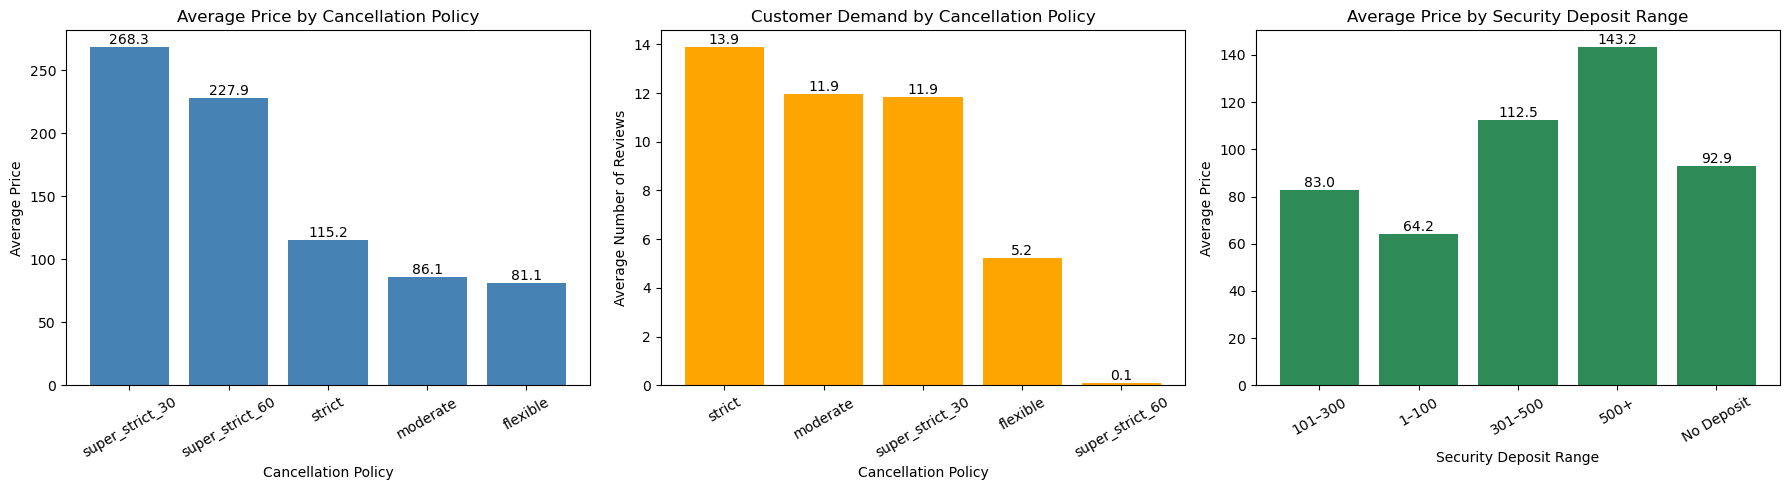

In [34]:
plt.figure(figsize=(18, 5))

# 1. How prices vary across different cancellation policies

plt.subplot(1, 3, 1)

avg_price_policy = (france_df.groupby("cancellation_policy")["price"].mean().sort_values(ascending=False))

ax1 = plt.bar(avg_price_policy.index,avg_price_policy.values,color=["steelblue"])

plt.bar_label(ax1, fmt="%.1f")
plt.title("Average Price by Cancellation Policy")
plt.xlabel("Cancellation Policy")
plt.ylabel("Average Price")
plt.xticks(rotation=30)


# 2. How customer demand differs by cancellation policy

plt.subplot(1, 3, 2)

avg_reviews_policy = (france_df.groupby("cancellation_policy")["number_of_reviews"].mean().sort_values(ascending=False))

ax2 = plt.bar(avg_reviews_policy.index,avg_reviews_policy.values,color=["orange"])

plt.bar_label(ax2, fmt="%.1f")
plt.title("Customer Demand by Cancellation Policy")
plt.xlabel("Cancellation Policy")
plt.ylabel("Average Number of Reviews")
plt.xticks(rotation=30)


# 3. How pricing changes across security deposit ranges

plt.subplot(1, 3, 3)

# Create simple security deposit ranges
france_df["security_deposit_range"] = pd.cut(
    france_df["security_deposit"],
    bins=[-1, 0, 100, 300, 500, france_df["security_deposit"].max()],
    labels=["No Deposit", "1–100", "101–300", "301–500", "500+"]
)

france_df["security_deposit_range"] = france_df["security_deposit_range"].astype(str)


avg_price_deposit = (france_df.groupby("security_deposit_range")["price"].mean())

ax3 = plt.bar(avg_price_deposit.index.astype(str),avg_price_deposit.values,color="seagreen")

plt.bar_label(ax3, fmt="%.1f")
plt.title("Average Price by Security Deposit Range")
plt.xlabel("Security Deposit Range")
plt.ylabel("Average Price")
plt.xticks(rotation=30)


plt.tight_layout()
plt.show()

## Cancellation & Security Policies Insights 

1. Stricter cancellation policies usually come with higher prices.
Listings with super-strict policies charge much more compared to moderate or flexible ones, showing that hosts price in the risk of cancellations.

2. Customers prefer flexibility when booking.
Listings with moderate and strict policies receive more reviews, while super-strict policies see very low customer demand.

3. Higher security deposits are linked to higher-priced listings.
Properties asking for larger security deposits generally have higher average prices, indicating premium or high-value accommodations.

## Market Competitiveness Analysis

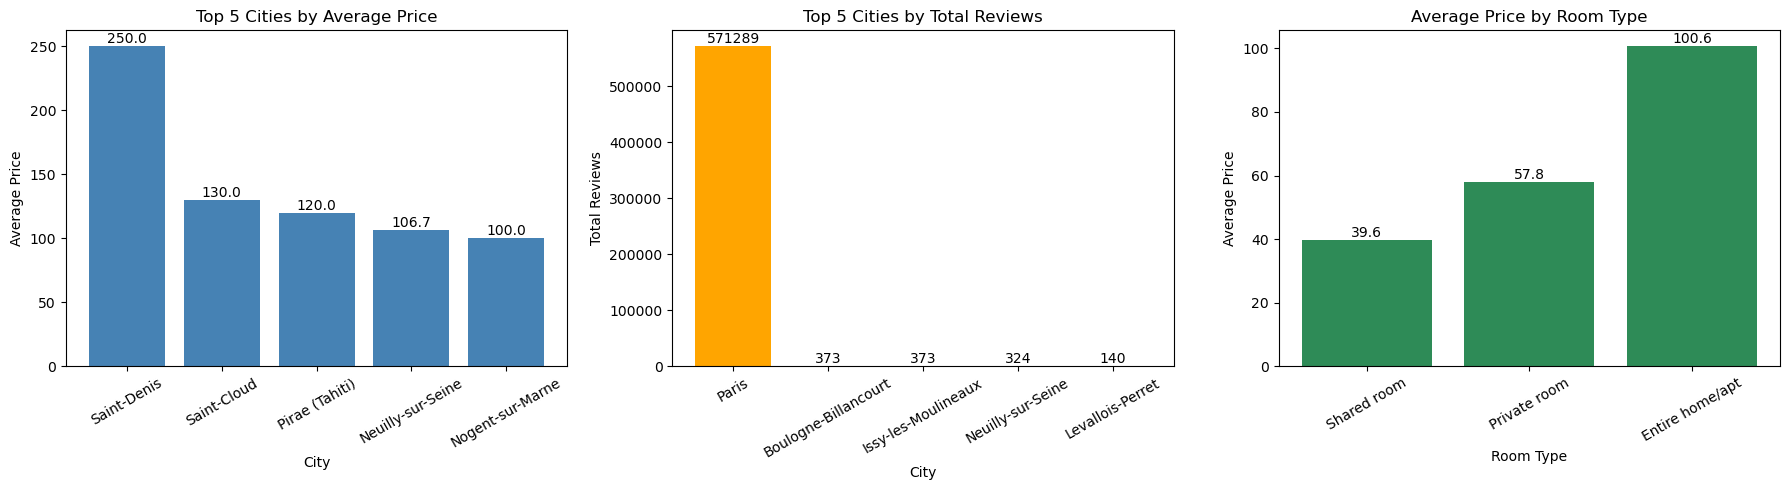

In [35]:
plt.figure(figsize=(18, 5))

# 1. City-wise price comparison

plt.subplot(1, 3, 1)

avg_price_city = (france_df.groupby("city")["price"].mean().sort_values(ascending=False).head(5))

ax1 = plt.bar(avg_price_city.index, avg_price_city.values, color="steelblue")
plt.bar_label(ax1, fmt="%.1f")

plt.title("Top 5 Cities by Average Price")
plt.xlabel("City")
plt.ylabel("Average Price")
plt.xticks(rotation=30)


# 2. City-wise customer engagement

plt.subplot(1, 3, 2)

total_reviews_city = (france_df.groupby("city")["number_of_reviews"].sum().sort_values(ascending=False).head(5))

ax2 = plt.bar(total_reviews_city.index, total_reviews_city.values, color="orange")
plt.bar_label(ax2)

plt.title("Top 5 Cities by Total Reviews")
plt.xlabel("City")
plt.ylabel("Total Reviews")
plt.xticks(rotation=30)


# 3. Room type price competitiveness

plt.subplot(1, 3, 3)

avg_price_room = (france_df.groupby("room_type")["price"].mean().sort_values())

ax3 = plt.bar(avg_price_room.index, avg_price_room.values, color="seagreen")
plt.bar_label(ax3, fmt="%.1f")

plt.title("Average Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price")
plt.xticks(rotation=30)


plt.tight_layout()
plt.show()

## Market Competitiveness – Insights

1. Saint-Denis stands out as the most expensive city, showing that certain locations command premium pricing, likely due to demand, property type, or proximity advantages.

2. Paris clearly dominates customer engagement, with an extremely high number of reviews compared to other cities, confirming it as the most competitive and active Airbnb market.

3. Entire homes are the least price-competitive room type, as they have much higher average prices than private and shared rooms, while shared rooms remain the most budget-friendly option.

#  STATISTICAL ANALYSIS

In [36]:
import math
from scipy.stats import norm
from scipy.stats import t

## LISTING & HOST PERFORMANCE — STATISTICS

### **Business Question**

Do listings managed by **multi-listing hosts** receive more customer engagement than **single-listing hosts**?

### **Null Hypothesis (H₀)**

There is **no significant difference** in average number of reviews between single-listing and multi-listing hosts.

### **Alternative Hypothesis (H₁)**

Listings owned by **multi-listing hosts** receive **significantly more reviews** than those owned by single-listing hosts.

### **Statistical Test Used**

**Two-sample, right-tailed Z-test**
(Comparing means of two independent groups)

### **Significance Level**

α = 0.05

In [37]:
single_hosts = france_df[france_df["host_listings_count"] == 1]["number_of_reviews"].dropna()
multi_hosts  = france_df[france_df["host_listings_count"] > 1]["number_of_reviews"].dropna()

mean1 = multi_hosts.mean()
mean2 = single_hosts.mean()
var1 = multi_hosts.var()
var2 = single_hosts.var()
n1 = len(multi_hosts)
n2 = len(single_hosts)

z_stat = (mean1 - mean2) / math.sqrt((var1/n1) + (var2/n2))
p_value = norm.sf(z_stat)
z_critical = norm.ppf(0.95)

print("Listing & Host Performance")
print("--------------------------------")
print("Test Statistic      :", round(z_stat, 3))
print("P-value (one-tailed):", round(p_value, 4))
print("Critical Value      :", round(z_critical, 3))

if z_stat > z_critical:
    print("\nConclusion:\nReject H₀ – Multi-listing hosts receive more reviews.")
else:
    print("\nConclusion:\nFail to Reject H₀ – No strong evidence found.")


Listing & Host Performance
--------------------------------
Test Statistic      : 23.501
P-value (one-tailed): 0.0
Critical Value      : 1.645

Conclusion:
Reject H₀ – Multi-listing hosts receive more reviews.


## CUSTOMER EXPERIENCE & SATISFACTION — STATISTICS

### **Business Question**

Is the **average customer review score** significantly **higher than 80** across Airbnb listings?

### **Null Hypothesis (H₀)**

The average review score is **less than or equal to 80**.

### **Alternative Hypothesis (H₁)**

The average review score is **greater than 80**.

### **Statistical Test Used**

**One-sample, right-tailed t-test**
(Mean compared to a benchmark value)

### **Significance Level**

α = 0.05

In [38]:
ratings = france_df["review_scores_rating"].dropna()

sample_mean = ratings.mean()
sample_var = ratings.var()
n = len(ratings)
benchmark = 80

z_stat = (sample_mean - benchmark) / math.sqrt(sample_var / n)
p_value = norm.sf(z_stat)
z_critical = norm.ppf(0.95)

print("\nCustomer Satisfaction Analysis")
print("--------------------------------")
print("Test Statistic      :", round(z_stat, 3))
print("P-value (one-tailed):", round(p_value, 4))
print("Critical Value      :", round(z_critical, 3))

if z_stat > z_critical:
    print("\nConclusion:\nReject H₀ – Customer ratings are higher than 80.")
else:
    print("\nConclusion:\nFail to Reject H₀ – Ratings are not significantly higher.")



Customer Satisfaction Analysis
--------------------------------
Test Statistic      : -72.084
P-value (one-tailed): 1.0
Critical Value      : 1.645

Conclusion:
Fail to Reject H₀ – Ratings are not significantly higher.


## GEOSPATIAL / LOCATION-BASED PRICING — STATISTICS

### **Business Question**

Are listings in **Paris** priced significantly higher than listings in **other cities**?

### **Null Hypothesis (H₀)**

There is **no significant difference** in average price between Paris and non-Paris listings.

### **Alternative Hypothesis (H₁)**

Listings in Paris have a **significantly higher average price**.

### **Statistical Test Used**

**Independent two-sample, right-tailed t-test**

### **Significance Level**

α = 0.05


In [39]:
paris_price = france_df[france_df["city"] == "Paris"]["price"].dropna()
other_price = france_df[france_df["city"] != "Paris"]["price"].dropna()

mean1 = paris_price.mean()
mean2 = other_price.mean()
var1 = paris_price.var()
var2 = other_price.var()
n1 = len(paris_price)
n2 = len(other_price)

t_stat = (mean1 - mean2) / math.sqrt((var1/n1) + (var2/n2))
df = n1 + n2 - 2
p_value = t.sf(t_stat, df)
t_critical = t.ppf(0.95, df)

print("\nGeospatial Pricing Analysis")
print("--------------------------------")
print("Test Statistic      :", round(t_stat, 3))
print("P-value (one-tailed):", round(p_value, 4))
print("Critical Value      :", round(t_critical, 3))

if t_stat > t_critical:
    print("\nConclusion:\nReject H₀ – Paris listings are priced higher.")
else:
    print("\nConclusion:\nFail to Reject H₀ – No significant price difference.")



Geospatial Pricing Analysis
--------------------------------
Test Statistic      : 7.304
P-value (one-tailed): 0.0
Critical Value      : 1.645

Conclusion:
Reject H₀ – Paris listings are priced higher.


## PROPERTY ATTRIBUTES & AMENITIES — STATISTICS

### **Business Question**

Do listings with **more amenities** receive **higher customer engagement** (reviews)?

### **Null Hypothesis (H₀)**

The average number of reviews for listings with many amenities is **less than or equal to** listings with fewer amenities.

### **Alternative Hypothesis (H₁)**

Listings with **more amenities** receive **significantly more reviews**.

### **Statistical Test Used**

**Two-sample, right-tailed Z-test**

### **Significance Level**

α = 0.05


In [40]:
high_amenities = france_df[france_df["amenity_count"] >= 5]["number_of_reviews"].dropna()
low_amenities  = france_df[france_df["amenity_count"] < 5]["number_of_reviews"].dropna()

mean1 = high_amenities.mean()
mean2 = low_amenities.mean()
var1 = high_amenities.var()
var2 = low_amenities.var()
n1 = len(high_amenities)
n2 = len(low_amenities)

z_stat = (mean1 - mean2) / math.sqrt((var1/n1) + (var2/n2))
p_value = norm.sf(z_stat)
z_critical = norm.ppf(0.95)

print("\nAmenities Impact Analysis")
print("--------------------------------")
print("Test Statistic      :", round(z_stat, 3))
print("P-value (one-tailed):", round(p_value, 4))
print("Critical Value      :", round(z_critical, 3))

if z_stat > z_critical:
    print("\nConclusion:\nReject H₀ – More amenities lead to higher engagement.")
else:
    print("\nConclusion:\nFail to Reject H₀ – Amenities impact is not strong.")



Amenities Impact Analysis
--------------------------------
Test Statistic      : 15.314
P-value (one-tailed): 0.0
Critical Value      : 1.645

Conclusion:
Reject H₀ – More amenities lead to higher engagement.


## CANCELLATION & SECURITY POLICIES — STATISTICS

### **Business Question**

Do listings with **strict cancellation policies** have **higher average prices** than flexible policies?

### **Null Hypothesis (H₀)**

Average prices under strict cancellation policies are **less than or equal to** flexible policies.

### **Alternative Hypothesis (H₁)**

Listings with strict cancellation policies have **significantly higher prices**.

### **Statistical Test Used**

**Independent two-sample, right-tailed t-test**

### **Significance Level**

α = 0.05

In [41]:
strict_price = france_df[france_df["cancellation_policy"] == "strict"]["price"].dropna()
flex_price   = france_df[france_df["cancellation_policy"] == "flexible"]["price"].dropna()

mean1 = strict_price.mean()
mean2 = flex_price.mean()
var1 = strict_price.var()
var2 = flex_price.var()
n1 = len(strict_price)
n2 = len(flex_price)

t_stat = (mean1 - mean2) / math.sqrt((var1/n1) + (var2/n2))
df = n1 + n2 - 2
p_value = t.sf(t_stat, df)
t_critical = t.ppf(0.95, df)

print("\nCancellation Policy Analysis")
print("--------------------------------")
print("Test Statistic      :", round(t_stat, 3))
print("P-value (one-tailed):", round(p_value, 4))
print("Critical Value      :", round(t_critical, 3))

if t_stat > t_critical:
    print("\nConclusion:\nReject H₀ – Strict policies are priced higher.")
else:
    print("\nConclusion:\nFail to Reject H₀ – No strong price difference.")



Cancellation Policy Analysis
--------------------------------
Test Statistic      : 44.148
P-value (one-tailed): 0.0
Critical Value      : 1.645

Conclusion:
Reject H₀ – Strict policies are priced higher.


# MACHINE LEARNING MODELS

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.neighbors import KNeighborsRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Encoding

In [43]:
france_encoded = france_df.copy()

categorical_cols = france_encoded.select_dtypes(include=["object"]).columns

le = LabelEncoder()

for col in categorical_cols:
    france_encoded[col] = le.fit_transform(france_encoded[col].astype(str))

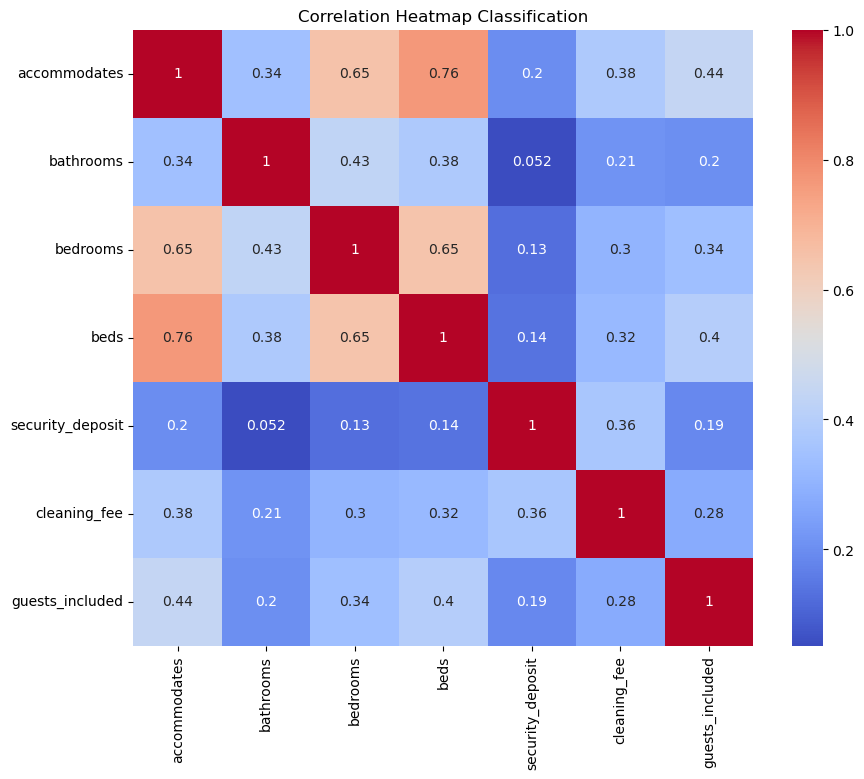

In [44]:
features = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'security_deposit', 'cleaning_fee', 'guests_included']

corr_df = france_encoded[features].dropna()

corr_matrix = corr_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap Classification")
plt.show()

## Simple Linear Regression: Price Prediction

In [45]:
features = ['accommodates']
target = 'price'

data = france_encoded[features + [target]].dropna()

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"--- Simple Linear Regression Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Intercept (C): {model.intercept_:.2f}")
print(f"Slope (Coefficient): {model.coef_[0]:.2f}")

--- Simple Linear Regression Model Evaluation ---
Mean Absolute Error (MAE): 37.33
Root Mean Squared Error (RMSE): 64.06
R-squared (R2) Score: 0.2918
Intercept (C): 93.97
Slope (Coefficient): 39.95


### Simple Linear Regression: Price Prediction

1. The model reports a Mean Absolute Error (MAE) of 37.33, which means that, on average, the predicted prices differ from the actual prices by about 37 units. This indicates moderate accuracy for a basic single-feature model.

2. The Root Mean Squared Error (RMSE) of 64.06 suggests that some predictions have larger errors, showing that the model is sensitive to higher price variations and outliers.

3. The R-squared value of 0.2918 indicates that nearly 29% of the variation in Airbnb prices is explained solely by the number of accommodations, which is reasonable for a simple linear regression.

4. The positive slope (coefficient) of 39.95 confirms a clear positive relationship: as accommodation capacity increases, the expected price also increases by roughly 40 units per additional guest capacity.

5. The intercept value of 93.97 represents the baseline predicted price when the accommodation feature is at its standardized reference level, serving as a starting point for price estimation.


## Multiple Linear Regression: Price Prediction

In [46]:
features = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'security_deposit', 'cleaning_fee', 'guests_included']
target = 'price'

data = france_encoded[features + [target]].dropna()

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"--- Multiple Linear Regression Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Intercept (C): {model.intercept_:.2f}")
print(f"Slope (Coefficient): {model.coef_[0]:.2f}")

coefficients = pd.DataFrame({'Feature': features, 'Coefficient (Slope)': model.coef_})
print("\n--- Feature Coefficients ---")
print(coefficients.sort_values(by='Coefficient (Slope)', ascending=False))

--- Multiple Linear Regression Model Evaluation ---
Mean Absolute Error (MAE): 33.31
Root Mean Squared Error (RMSE): 57.06
R-squared (R2) Score: 0.4381
Intercept (C): 93.97
Slope (Coefficient): 17.37

--- Feature Coefficients ---
            Feature  Coefficient (Slope)
0      accommodates            17.365601
1         bathrooms            16.262366
2          bedrooms            14.944608
5      cleaning_fee            13.476077
3              beds             3.287740
4  security_deposit             0.707484
6   guests_included            -0.626940


### Multiple Linear Regression: Price Prediction

1. The model records a MAE of 33.31 and an RMSE of 57.06, showing improved price estimation compared to simple regression by using multiple property features together.

2. The R-squared value of 0.4381 indicates that around 44% of the variation in listing prices is explained by the model, reflecting a reasonably good fit for real-world pricing data.

3. Accommodates is the strongest predictor (≈ 17.37), confirming that listings allowing more guests tend to have higher prices.

4. Bathrooms, bedrooms, and cleaning fees also have notable positive effects, showing that property size and additional costs contribute meaningfully to pricing.

5. Variables like security deposit and guests included have minimal or negative influence, suggesting they play a smaller role in determining nightly prices compared to core property features.

## KNN Regression: Price Prediction

In [47]:
model = KNeighborsRegressor(n_neighbors=5)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"--- KNN Regression Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

--- KNN Regression Model Evaluation ---
Mean Absolute Error (MAE): 32.86
Root Mean Squared Error (RMSE): 56.73
R-squared (R2) Score: 0.4446


## Logistic Regression: Room Type Classification

In [48]:
features = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'amenity_count']
target = 'room_type'

data = france_encoded[features + [target]].dropna()
X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


print(f"--- Logistic Regression Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

--- Logistic Regression Model Evaluation ---
Accuracy Score: 0.8792

Confusion Matrix:
[[9611   98    0]
 [1153  307    1]
 [  63   49   11]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      9709
           1       0.68      0.21      0.32      1461
           2       0.92      0.09      0.16       123

    accuracy                           0.88     11293
   macro avg       0.83      0.43      0.47     11293
weighted avg       0.86      0.88      0.85     11293



### Logistic Regression: Room Type Classification

1. The model achieves an overall accuracy of 87.92%, indicating strong performance in predicting room types using listing features such as price, capacity, and amenities.

2. Room Type 0 is classified very well, with high precision (0.89) and excellent recall (0.99), meaning the model correctly identifies most listings belonging to this category.

3. Room Type 1 shows moderate performance, with lower recall (0.21), suggesting that many listings of this type are misclassified as other room types.

4. Room Type 2 performs poorly due to very low support (only 123 listings), resulting in low recall (0.09) and F1-score (0.16), highlighting a clear class imbalance issue.

5. The weighted F1-score of 0.85 confirms that the model performs well overall for the majority of listings, but improvements such as class balancing or alternative models could help better identify minority room types.

## K-NEAREST NEIGHBOURS: Room Type Classification

In [49]:
features = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'amenity_count']
target = 'room_type' 

data = france_encoded[features + [target]].dropna()
X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_clf = KNeighborsClassifier(n_neighbors=11)
knn_clf.fit(X_train_scaled, y_train)

y_pred = knn_clf.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"--- KNN Classification Evaluation ---")
print(f"Accuracy Score: {acc:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nDetailed Classification Report:")
print(report)

--- KNN Classification Evaluation ---
Accuracy Score: 0.8951

Confusion Matrix:
[[9425  283    1]
 [ 791  663    7]
 [  38   65   20]]

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      9709
           1       0.66      0.45      0.54      1461
           2       0.71      0.16      0.26       123

    accuracy                           0.90     11293
   macro avg       0.76      0.53      0.58     11293
weighted avg       0.88      0.90      0.88     11293



### KNN: Room Type Classification

1. The KNN model achieves a strong overall accuracy of about 89.5%, showing that it predicts room types reliably using listing features such as price, size, and amenities.

2. Room types 0 and 1 are classified very well, with high precision and recall, indicating that these common room categories are easy for the model to distinguish.

3. Room type 2 shows weaker performance because it has very few listings, which makes it harder for the model to learn its patterns properly.

4. The confusion matrix reveals that most prediction errors occur between room types 0 and 1, suggesting that these room types share similar characteristics like capacity and pricing.

5. Overall, the model performs well for practical use, but handling class imbalance or tuning the value of k could further improve predictions for rare room types.

## K-Means: Price Clustering

In [50]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

K = 2, Inertia = 70139.10, Silhouette = 0.421
K = 3, Inertia = 44485.08, Silhouette = 0.435
K = 4, Inertia = 35665.06, Silhouette = 0.356
K = 5, Inertia = 27845.52, Silhouette = 0.375
K = 6, Inertia = 23801.15, Silhouette = 0.385
K = 7, Inertia = 20367.54, Silhouette = 0.357
K = 8, Inertia = 18150.11, Silhouette = 0.354
K = 9, Inertia = 16558.18, Silhouette = 0.328
K = 10, Inertia = 15039.35, Silhouette = 0.346
K = 11, Inertia = 13580.52, Silhouette = 0.348


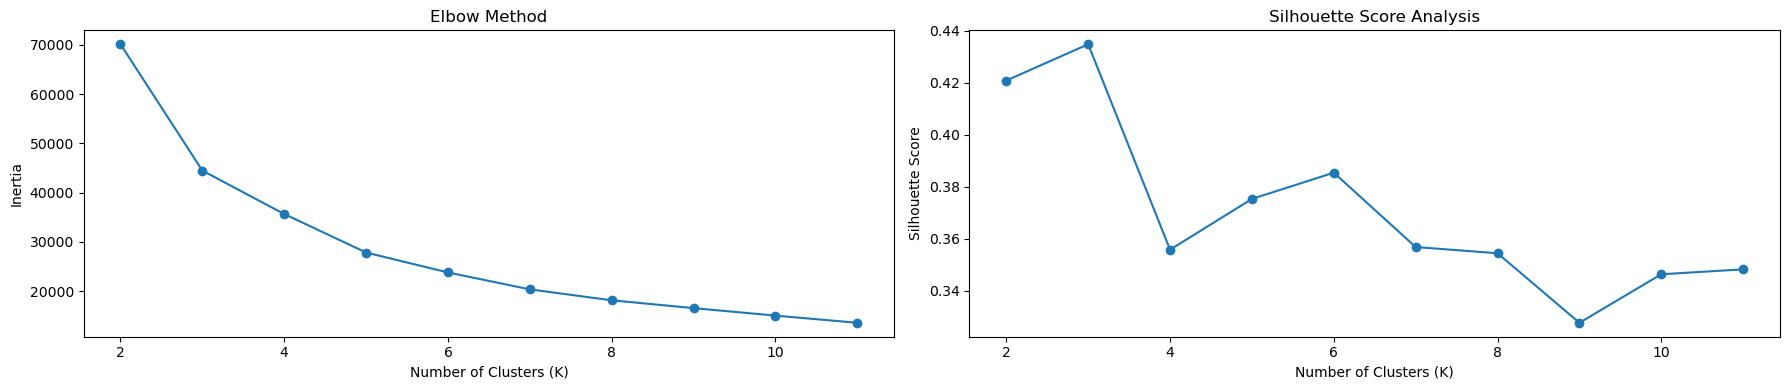

In [51]:
features = ['price', 'amenity_count']
data_clustering = france_encoded[features].dropna()

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_clustering)

# 1. Finding Optimal K

inertia_scores = []
silhouette_scores = []

for k in range(2, 12):
    model = KMeans(n_clusters=k, random_state=3, n_init=10)
    labels = model.fit_predict(data_scaled)

    inertia_scores.append(model.inertia_)
    silhouette_scores.append(silhouette_score(data_scaled, labels))

    print(f"K = {k}, Inertia = {model.inertia_:.2f}, Silhouette = {silhouette_score(data_scaled, labels):.3f}")

# 2. Elbow Plot

plt.figure(figsize=(18,4))
plt.subplot(1,2,1)
plt.plot(range(2, 12), inertia_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

# 3. Silhouette Score Plot

plt.subplot(1,2,2)
plt.plot(range(2, 12), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Analysis")

plt.tight_layout()
plt.show()


Cluster Distribution:
cluster
1.0    18544
3.0    14747
2.0    13598
4.0     6951
0.0     2622
Name: count, dtype: int64

Cluster Centroids:
        price  amenity_count
0  342.349733      15.935927
1   64.840992      11.705448
2   69.518164       7.339315
3  105.989018      14.892685
4  103.747087      19.851676


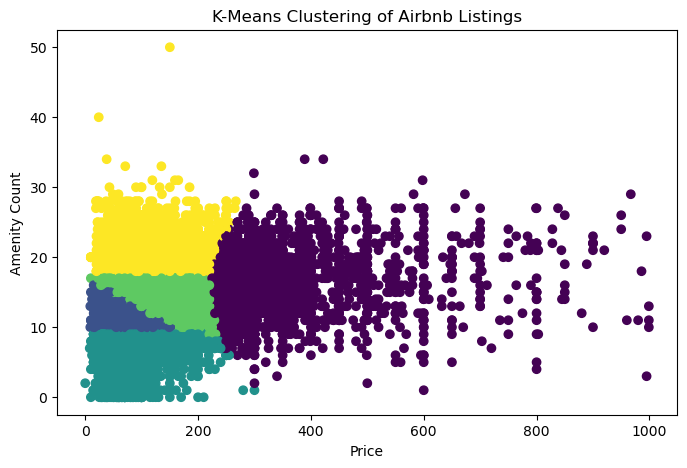

In [52]:
# 4. Final Model (Chosen K)

final_k = 5  
final_model = KMeans(n_clusters=final_k, random_state=3)
france_encoded.loc[data_clustering.index, "cluster"] = final_model.fit_predict(data_scaled)

# 5. Cluster Distribution

print("\nCluster Distribution:")
print(france_encoded["cluster"].value_counts())

# 6. Cluster Centroids

centroids = pd.DataFrame(scaler.inverse_transform(final_model.cluster_centers_), columns=features)

print("\nCluster Centroids:")
print(centroids)

# 7. Cluster Visualization

plt.figure(figsize=(8,5))
plt.scatter(data_clustering["price"],data_clustering["amenity_count"], c=france_encoded.loc[data_clustering.index, "cluster"],cmap="viridis")
plt.xlabel("Price")
plt.ylabel("Amenity Count")
plt.title("K-Means Clustering of Airbnb Listings")
plt.show()


### K-Means: Price Clustering

1. Even though fewer clusters (like 2 or 3) give slightly better technical scores, choosing 5 clusters makes more sense from a business point of view because it clearly separates listings into budget, mid-range, and premium groups.

2. The elbow chart shows that after 5 clusters, the improvement becomes very small, which means adding more clusters does not really give useful new insights.

3. The cluster centers clearly show different types of listings, such as low-priced homes with fewer amenities, moderately priced listings with balanced features, and high-priced homes offering many amenities.

4. Most listings belong to the budget and mid-range groups, while high-end and premium listings are fewer, showing that luxury options are a smaller part of the market.

5. This clustering helps understand the market better by showing how price and amenities go together, which can support better pricing decisions and highlight where hosts can improve their listings.